# Blood Sugar Level Prediction

**Objective:** Build and evaluate a regression model that predicts a person's blood sugar level (mg/dL) from a set of health and lifestyle indicators, then package the trained model for use in a web application.

**Dataset features:**
- `Age`
- `BMI`
- `Physical_Activity_Min`
- `Sleep_Hours`
- `Stress_Level`
- `Daily_Carb_Intake_g`
- `Family_History`
- `Previous_Glucose`

**Target variable:** `Blood_Sugar_mg_dL`

**Workflow:**
1. Load and inspect the dataset
2. Explore the data through summary statistics and visualizations
3. Examine correlations between features and the target
4. Split the data into training and test sets
5. Train a Linear Regression model
6. Evaluate model performance
7. Save the trained model
8. Run an interactive prediction on new input


## 1. Import Libraries
Load the core library needed to read and manipulate the dataset.

In [44]:
import pandas as pd

## 2. Load the Dataset
Read the blood sugar dataset from CSV into a pandas DataFrame.

In [45]:
df = pd.read_csv("blood_sugar_dataset.csv")

## 3. Initial Data Inspection
Get a first look at the data, its structure, and its quality before any analysis or modeling.

**Preview the first few rows of the dataset.**

In [46]:
df.head()

,Age,BMI,Physical_Activity_Min,Sleep_Hours,Stress_Level,Daily_Carb_Intake_g,Family_History,Previous_Glucose,Blood_Sugar_mg_dL
0,56,20.1,63,5.8,3,276,1,101.6,89.8
1,69,24.0,74,5.5,5,302,0,114.4,101.7
2,46,23.4,60,7.2,5,172,0,89.8,73.4
3,32,22.6,62,8.0,4,301,1,102.8,84.6
4,60,33.4,45,8.7,1,187,0,81.8,70.0


**Summary statistics** for all numeric columns (mean, standard deviation, min/max, quartiles).

In [47]:
df.describe()

,Age,BMI,Physical_Activity_Min,Sleep_Hours,Stress_Level,Daily_Carb_Intake_g,Family_History,Previous_Glucose,Blood_Sugar_mg_dL
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.732000,25.453800,49.976000,7.08360,5.500000,250.920000,0.358000,100.592800,86.029600
std,15.239707,4.368232,23.216404,1.01065,2.835857,57.837565,0.479892,11.759556,13.767784
min,18.000000,17.000000,10.000000,4.50000,1.000000,150.000000,0.000000,70.000000,70.000000
25%,32.000000,22.375000,29.000000,6.40000,3.000000,199.750000,0.000000,91.900000,73.725000
50%,45.000000,25.400000,49.000000,7.10000,5.000000,253.000000,0.000000,100.900000,84.600000
75%,57.000000,28.325000,70.000000,7.72500,8.000000,302.250000,1.000000,108.325000,95.125000
max,70.000000,39.400000,90.000000,9.50000,10.000000,350.000000,1.000000,144.700000,149.300000


**Check for missing values** in each column.

In [48]:
df.isnull().sum()

Age                      0
BMI                      0
Physical_Activity_Min    0
Sleep_Hours              0
Stress_Level             0
Daily_Carb_Intake_g      0
Family_History           0
Previous_Glucose         0
Blood_Sugar_mg_dL        0
dtype: int64

**Check for duplicate rows.**

In [49]:
df.duplicated().sum()

np.int64(0)

**Review data types** of each column to confirm they are suitable for analysis and modeling.

In [50]:
pd.DataFrame(df.dtypes)

,0
Age,int64
BMI,float64
Physical_Activity_Min,int64
Sleep_Hours,float64
Stress_Level,int64
Daily_Carb_Intake_g,int64
Family_History,int64
Previous_Glucose,float64
Blood_Sugar_mg_dL,float64


**List all column names** in the dataset.

In [51]:
pd.DataFrame(df.columns)

,0
0,Age
1,BMI
2,Physical_Activity_Min
3,Sleep_Hours
4,Stress_Level
5,Daily_Carb_Intake_g
6,Family_History
7,Previous_Glucose
8,Blood_Sugar_mg_dL


**Check the shape** of the dataset (number of rows and columns).

In [52]:
df.shape

(500, 9)

## 4. Exploratory Data Analysis (EDA)
Visualize individual features and their relationship with the target variable, `Blood_Sugar_mg_dL`, to understand patterns and potential predictors.

Import the plotting library used throughout the EDA section.

In [53]:
import matplotlib.pyplot as plt

### Age vs. Blood Sugar Level
Scatter plot to observe how blood sugar level varies with age.

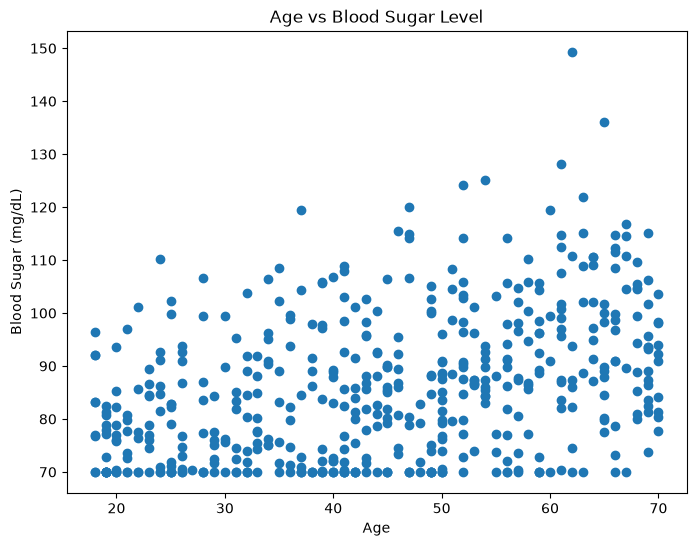

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(df["Age"], df["Blood_Sugar_mg_dL"])

plt.xlabel("Age")
plt.ylabel("Blood Sugar (mg/dL)")
plt.title("Age vs Blood Sugar Level")

plt.show()

### Distribution of Physical Activity
Histogram showing how physical activity minutes are distributed across the dataset.

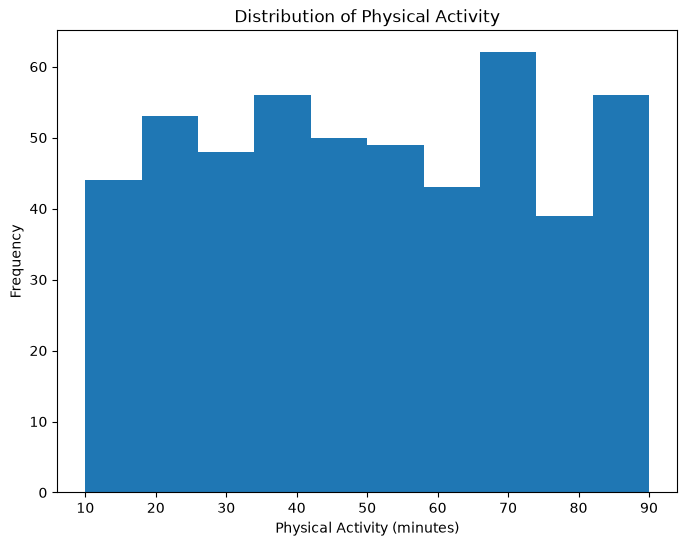

In [55]:
plt.figure(figsize=(8, 6))

plt.hist(df["Physical_Activity_Min"], bins="auto")

plt.xlabel("Physical Activity (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Physical Activity")

plt.show()

### Physical Activity vs. Blood Sugar Level
Scatter plot to check whether more physical activity is associated with lower blood sugar.

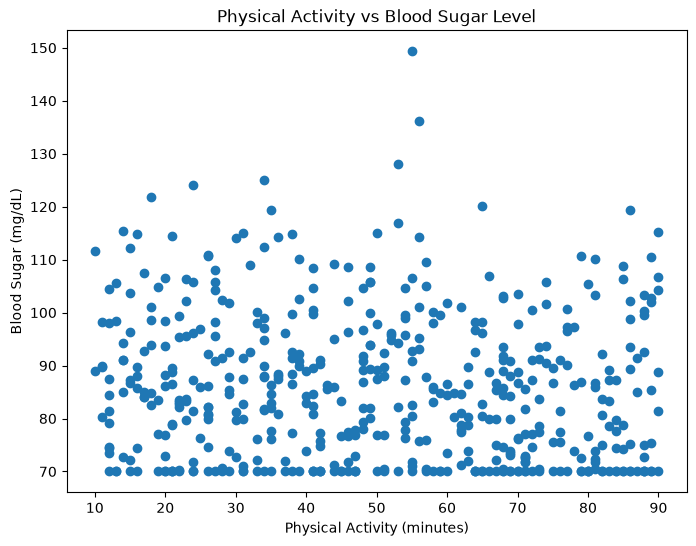

In [56]:
plt.figure(figsize=(8, 6))

plt.scatter(df["Physical_Activity_Min"], df["Blood_Sugar_mg_dL"])

plt.xlabel("Physical Activity (minutes)")
plt.ylabel("Blood Sugar (mg/dL)")
plt.title("Physical Activity vs Blood Sugar Level")

plt.show()

### Sleep Hours vs. Blood Sugar Level
Scatter plot to explore the relationship between sleep duration and blood sugar.

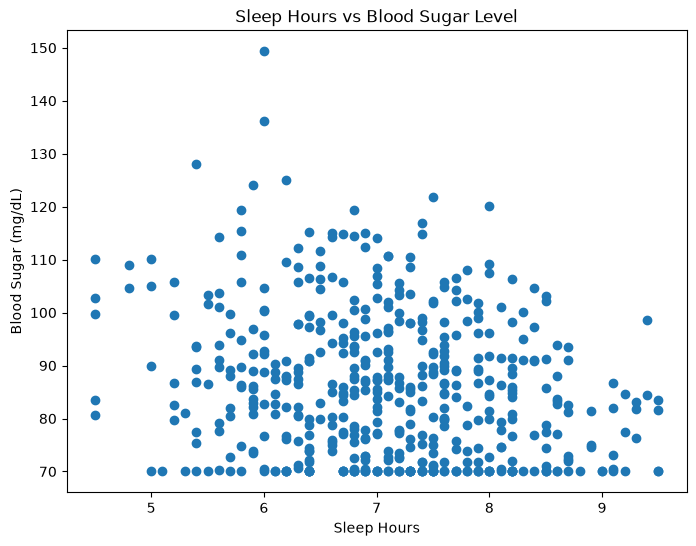

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(df["Sleep_Hours"], df["Blood_Sugar_mg_dL"])

plt.xlabel("Sleep Hours")
plt.ylabel("Blood Sugar (mg/dL)")
plt.title("Sleep Hours vs Blood Sugar Level")

plt.show()

### Stress Level Distribution
Pie chart showing the proportion of records at each stress level (1–10).

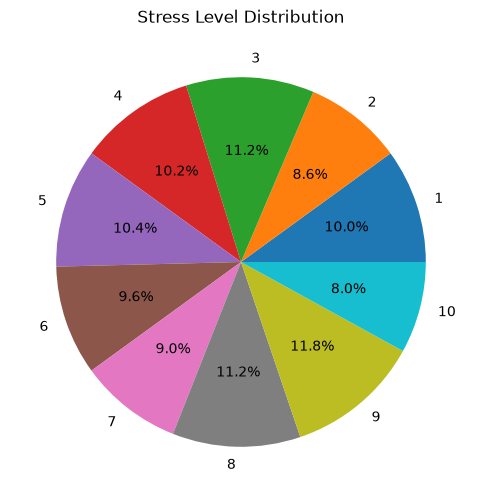

In [58]:
stress_counts = df["Stress_Level"].value_counts().sort_index()

plt.figure(figsize=(8, 6))

plt.pie(stress_counts, labels=stress_counts.index, autopct="%1.1f%%" )

plt.title("Stress Level Distribution")

plt.show()

### Family History Distribution
Pie chart showing the proportion of individuals with and without a family history of high blood sugar.

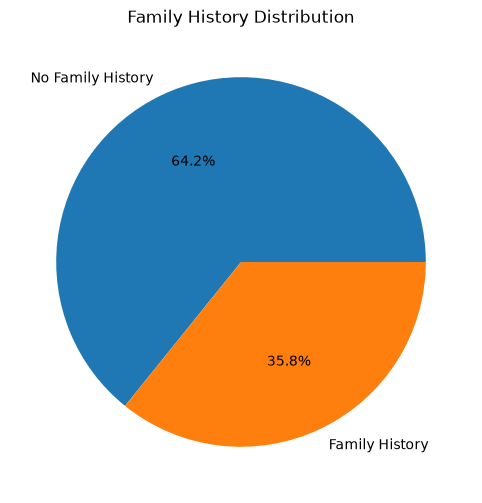

In [59]:
fam = df["Family_History"].value_counts().sort_index()

plt.figure(figsize=(8, 6))

plt.pie(
    fam,
    labels=["No Family History", "Family History"],
    autopct="%1.1f%%"
)

plt.title("Family History Distribution")

plt.show()

### Daily Carb Intake vs. Blood Sugar Level
Scatter plot to examine whether higher daily carbohydrate intake correlates with higher blood sugar.

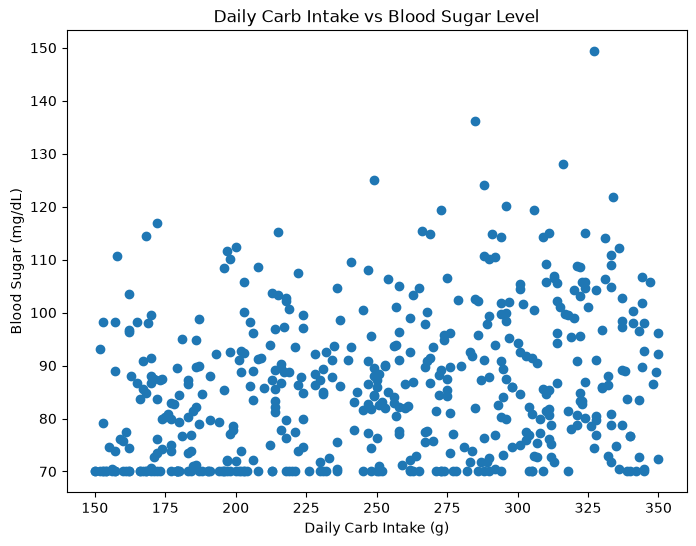

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Daily_Carb_Intake_g"],
    df["Blood_Sugar_mg_dL"]
)

plt.xlabel("Daily Carb Intake (g)")
plt.ylabel("Blood Sugar (mg/dL)")
plt.title("Daily Carb Intake vs Blood Sugar Level")

plt.show()

### Previous Glucose vs. Blood Sugar Level
Scatter plot to see how strongly a person's previous glucose reading predicts their current blood sugar level.

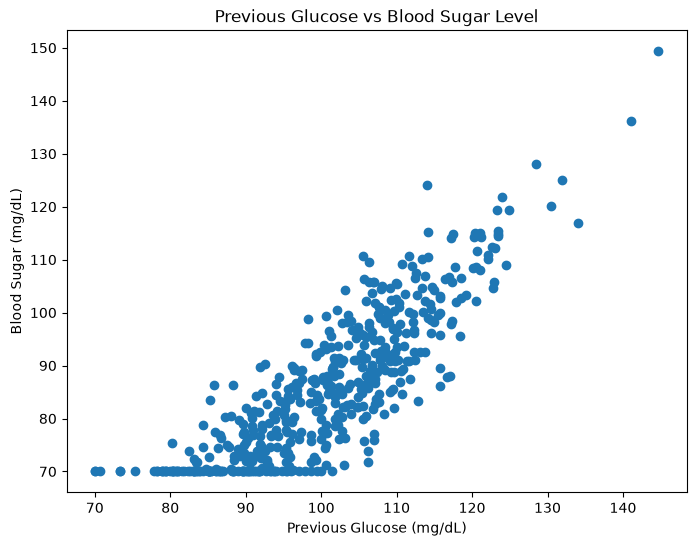

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Previous_Glucose"],
    df["Blood_Sugar_mg_dL"]
)

plt.xlabel("Previous Glucose (mg/dL)")
plt.ylabel("Blood Sugar (mg/dL)")
plt.title("Previous Glucose vs Blood Sugar Level")

plt.show()

## 5. Correlation Analysis
Quantify the linear relationship between every pair of numeric features and the target variable.

Compute the correlation matrix for all numeric columns.

In [62]:
corr = df.corr(numeric_only=True)
print(corr)

                            Age       BMI  Physical_Activity_Min  Sleep_Hours  \
Age                    1.000000  0.044373              -0.014309    -0.018424   
BMI                    0.044373  1.000000               0.008672    -0.013840   
Physical_Activity_Min -0.014309  0.008672               1.000000    -0.068925   
Sleep_Hours           -0.018424 -0.013840              -0.068925     1.000000   
Stress_Level           0.005935 -0.034984               0.044409     0.000979   
Daily_Carb_Intake_g   -0.060802 -0.010641               0.025289    -0.029171   
Family_History        -0.044947 -0.012648              -0.051210    -0.017207   
Previous_Glucose       0.377065  0.261265              -0.131626    -0.212169   
Blood_Sugar_mg_dL      0.394793  0.346975              -0.111405    -0.211749   

                       Stress_Level  Daily_Carb_Intake_g  Family_History  \
Age                        0.005935            -0.060802       -0.044947   
BMI                       -0.034984  

Import Seaborn for a clearer, annotated visualization of the correlation matrix.

In [63]:
import seaborn as sns

Visualize the correlation matrix as a heatmap.

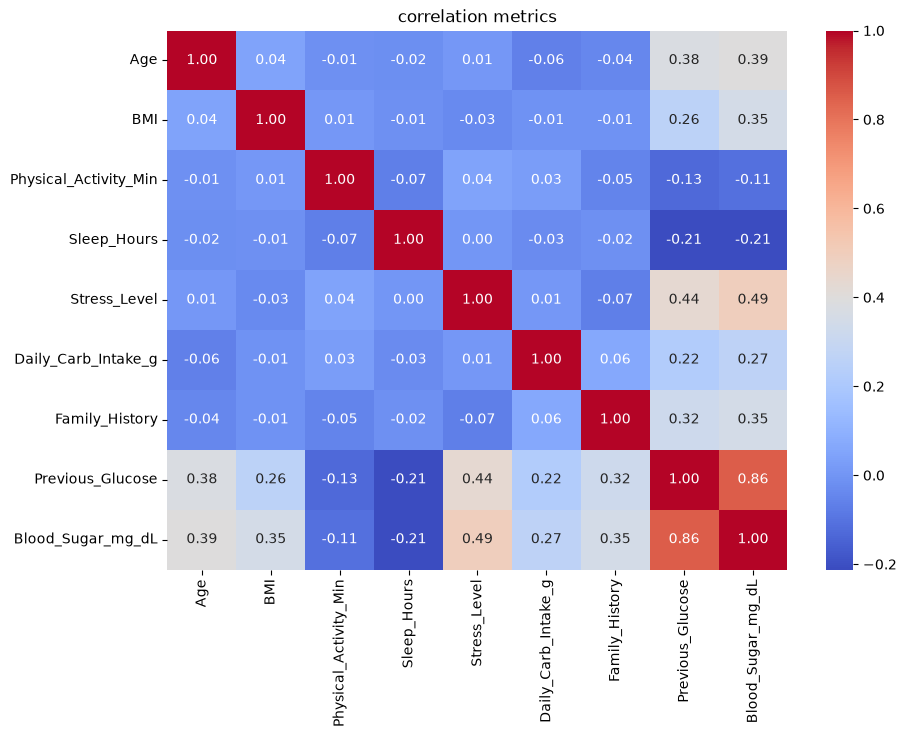

In [64]:
plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("correlation metrics")
plt.show()

## 6. Define Features and Target
Separate the dataset into input features (`x`) and the target variable (`y`), `Blood_Sugar_mg_dL`.

In [65]:
x = df.drop("Blood_Sugar_mg_dL", axis=1)
y = df["Blood_Sugar_mg_dL"]

## 7. Train-Test Split
Split the data into training and test sets so the model can be evaluated on unseen data.

Import the train-test split utility from scikit-learn.

In [67]:
from sklearn.model_selection import train_test_split

Split the data using an 80/20 train-test ratio with a fixed random state for reproducibility.

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=42, test_size=0.2) 

Confirm the shape of the training set.

In [72]:
x_train.shape

(400, 8)

Confirm the shape of the test set.

In [74]:
x_test.shape

(100, 8)

## 8. Model Training — Linear Regression
Train a Linear Regression model on the training data and generate predictions on the test set.

Import the Linear Regression model from scikit-learn.

In [76]:
from sklearn.linear_model import LinearRegression

Fit the model on the training data and predict blood sugar values for the test set.

In [88]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(y_pred)

[131.21766266  78.45591583  96.68174156  78.44790712  88.85296825
  82.18052668  87.38150756 112.69458128  91.46364011  91.68393955
  87.63553312  67.48238623 107.65021581  77.52109783  91.37678174
  95.45376822  86.58345011  89.48638178  92.43909481  76.3939372
  73.30828484  64.71116128  75.99077368  65.23917518  83.15105798
 100.62742336  80.55423808  97.19788042  98.553817    69.69724696
  83.18521671 111.03048731  77.2435963   92.3580498   72.78673834
  96.81997961  77.36010704 103.42579529  89.47479865  84.06221461
 108.48901543  79.58536289  65.53108052  96.68805664  75.2968957
 104.7834413   88.20209146  72.47089461  74.76536279 101.8315872
  67.06655719  66.74518122  84.93012083 103.11907367  81.17298209
 105.48086017  79.77081467  94.68251051  93.65911727  77.86612707
  81.5610113   70.03233681  82.7956847   83.12411128 112.03883218
 106.08461459  83.29334798  94.20647469  69.07848341  93.96693693
  97.20629618  78.30246764  86.25690244  86.22253788  99.88766789
  89.62678926

## 9. Model Evaluation
Assess model performance on the test set using standard regression metrics: MAE, MSE, RMSE, and R².

Import evaluation metrics from scikit-learn and NumPy for numerical operations.

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import numpy as np

Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score.

In [92]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

Print the evaluation results.

In [93]:
print(mae)
print(mse)
print(rmse)
print(r2)

4.0193716208386
26.136910928452167
5.112427107397441
0.8750536531898743


### Actual vs. Predicted Blood Sugar
Scatter plot comparing actual test-set values to predicted values, with a dashed diagonal line representing perfect predictions.

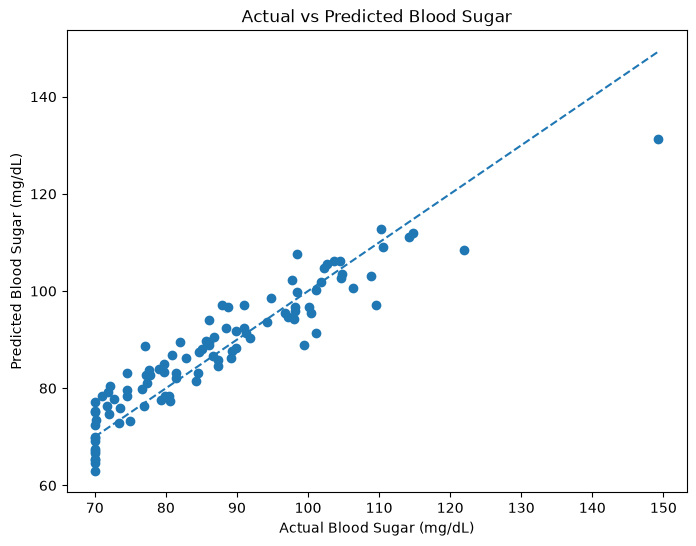

In [94]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Blood Sugar (mg/dL)")
plt.ylabel("Predicted Blood Sugar (mg/dL)")
plt.title("Actual vs Predicted Blood Sugar")

plt.show()

## 10. Save the Trained Model
Persist the trained model to disk with `joblib` so it can be loaded later by the Flask backend without retraining.

In [95]:
import joblib
joblib.dump(model, "blood_sugar_model.pkl")

['blood_sugar_model.pkl']

## 11. Interactive Prediction
Collect health and lifestyle inputs from the user, build a single-row DataFrame with the exact feature names and order used during training, and generate a blood sugar prediction with the trained model.

In [97]:
age = float(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
physical_activity = float(input("Enter Physical Activity (minutes/day): "))
sleep_hours = float(input("Enter Sleep Hours: "))
stress_level = float(input("Enter Stress Level (1-10): "))
carb_intake = float(input("Enter Daily Carb Intake (g): "))
family_history = int(input("Family History? (0 = No, 1 = Yes): "))
previous_glucose = float(input("Enter Previous Glucose (mg/dL): "))

user_input = pd.DataFrame([{
    "Age": age,
    "BMI": bmi,
    "Physical_Activity_Min": physical_activity,
    "Sleep_Hours": sleep_hours,
    "Stress_Level": stress_level,
    "Daily_Carb_Intake_g": carb_intake,
    "Family_History": family_history,
    "Previous_Glucose": previous_glucose
}])

prediction = model.predict(user_input)

print("\nPredicted Blood Sugar:", round(prediction[0], 2), "mg/dL")


Predicted Blood Sugar: 104.86 mg/dL


## Conclusion
The Linear Regression model was trained on eight health and lifestyle features and evaluated on a held-out test set, achieving the performance reported above. The trained model has been saved as `blood_sugar_model.pkl` and is ready to be served through the Flask application (`app.py`) for real-time predictions.